In [1]:
import ui
import construct
import ifc

import ui.comms

from configs.system_config import *
from configs.construction_config import *

import construct.analysis as analysis
 
from ui.mobility import moveJ, moveL, translate, set_orientation, gripper_width
# from construct.marker_pose import align_with_random_part
from construct.construction import rotation_matrix_to_vector
import ui.MarkerDetectionLocalization as mdl

from ui.comms import QuestionBoard
import matplotlib.pyplot as plt

import os

# import time
# ui.show_project_structure()

[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Advertised topic: /image
[FrameHandler] Subscribed to topic: /image
Robot data listener started on tcp://127.0.0.1:5560...
Listening for tracking messages...
[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Advertised topic: /image
[FrameHandler] Subscribed to topic: /image


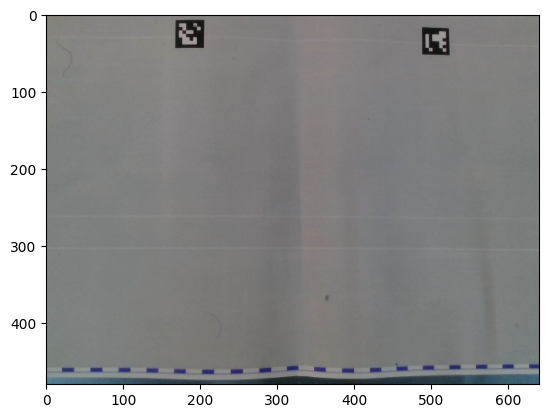

In [2]:
framehandler = ui.initializeUI()
packet = ui.comms.get_current_packet()
packet
files = []

In [3]:
# Construction
board = QuestionBoard(bg="white") 

if not construct.check_resume():
    ui.comms.refresh_tracking_packets() #Refresh stored data

script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v1.ifc", "--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

block_list, pl_pos,verfied,img = construct.construct_and_verify(board, framehandler, IFC_sorted)

if not verfied:
    plt.imshow(img)
    plt.show()
    path = ui.comms.save_failed_run("assembly_run",block_list, pl_pos)
    files.append(path)

else:   
    assembly_data = ui.load_data(10) 

board.close() # All done

Performing site scan
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Positions saved successfully.
Finished scanning
Searching for Foundation
The item is here:
We can't see the correct marker!
Unable to find fiducial marker. Please check the setup.
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
We can't see the correct marker!
Debug: Calculated angle: 0
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on Foundation
Searchi

In [4]:
# block_list = [
#     {'coords': [0.6400449644845064, -0.09275249867434224, 0.19698997061081222],
#      'orientation': [[-0.013486895711462887, -0.9998613908684063, 0.009762309909268758],
#                      [-0.998972784647309, 0.0138960252612087, 0.04313091717018525],
#                      [-0.043260596136318386, -0.009170579732838191, -0.9990217321406447]]},
#     {'coords': [0.6406049242016628, -0.015205470629027268, 0.19700068520508301],
#      'orientation': [[-0.013363172076250707, -0.9998626708909253, 0.009801274964324445],
#                      [-0.9989763439236712, 0.013773698665178635, 0.0430876955287281],
#                      [-0.0432167781417822, -0.009215453539931941, -0.9990232156977621]]},
#     {'coords': [0.5770556752115622, 0.05041533401967871, 0.19699667970298296],
#      'orientation': [[-0.013591856199712371, -0.9998604632140021, 0.00971161915067062],
#                      [-0.998966692486322, 0.013999679643749818, 0.043238365750926724],
#                      [-0.04336829196526953, -0.009113894412035077, -0.9990175815172931]]}
# ]

# pl_pos = [
#     {'coords': [0.591317791818959, 0.2736108006708059, 0.19996086931196425],
#      'orientation': [[-0.9986889024077946, 0.0510742120495988, 0.0034497928962748422],
#                      [0.05113208959407455, 0.9985006952723076, 0.019541518734776164],
#                      [-0.0024465529338447323, 0.019692293016068292, -0.9998030946013876]]},
#     {'coords': [0.5909667236503904, 0.2756588631807408, 0.2050017182391274],
#      'orientation': [[-0.06446118656760069, -0.9977456316637128, -0.018665741942823316],
#                      [-0.997913643088244, 0.0645173677228682, -0.0024228496571958354],
#                      [0.003621652198390362, 0.0184706187793301, -0.9998228442465508]]},
#     {'coords': [0.5953138292985872, 0.27782190762925896, 0.21495837562665818],
#      'orientation': [[-0.044645033535928524, -0.9989953825521661, 0.003878997296655773],
#                      [-0.9988262868583645, 0.04470981548885522, 0.018630112175861642],
#                      [-0.018784825293529914, -0.00304270248368286, -0.9998189197551162]]},
#     {'coords': [0.596159389953829, 0.2900118162052277, 0.2719614982389425],
#      'orientation': [[-0.04474456522858106, -0.9989904592634473, 0.003998272516006175],
#                      [-0.9988222501977209, 0.04481148318470507, 0.018602244078307437],
#                      [-0.018762632876737965, -0.003161214227781174, -0.999818968779918]]},
#     {'coords': [0.5946843411732964, 0.28253486617038476, 0.28141065223378103],
#      'orientation': [[-0.9979162090141581, 0.06447323434139683, -0.0025380780859378996],
#                      [0.06441468489881717, 0.9977473928806617, 0.01873201455339716],
#                      [0.0037400743571597097, 0.018529491450169848, -0.9998213189317384]]},
#     {'coords': [0.5975439806267154, 0.28274720180213686, 0.2879339554084096],
#      'orientation': [[-0.044755138004780814, -0.9989902558598273, 0.003930180567109841],
#                      [-0.9988206144709858, 0.04482097718169775, 0.018667086336119583],
#                      [-0.018824391888595967, -0.00309009734390239, -0.9998180302277159]]},
#     {'coords': [0.5960324845091386, 0.2899972073511868, 0.3439259660654773],
#      'orientation': [[-0.04559805949793916, -0.9989522380890861, 0.003904226790060611],
#                      [-0.9987824794062883, 0.04566326403242493, 0.01866614981543283],
#                      [-0.01882487187338981, -0.003048333103659641, -0.999818149397299]]},
#     {'coords': [0.5914810539533049, 0.2837986471554788, 0.35501756706920373],
#      'orientation': [[-0.9979125619435535, 0.06452554358639671, -0.002640632525288702],
#                      [0.06446511004806903, 0.997744256741268, 0.01872559014571428],
#                      [0.003842954819399281, 0.01851627296987545, -0.9998211736773537]]}
# ]


In [5]:
# Deconstruction
file_index = "00"
test_base = "_workingdata/Development/Fake_fail"
os.makedirs(test_base, exist_ok=True)

ui.comms.refresh_tracking_packets() #Refresh stored data

if not construct.check_resume():
    saved_paths = None
else:
    saved_paths = ui.comms.get_saved_paths(test_base, file_index)

dis_pos = construct.disassembly(
    pl_pos,
    block_list,
    framehandler,
    saved_paths=saved_paths
)

disassembly_data = ui.load_data(10)

Using stub file for site scan
Finished scanning
Unable to find fiducial marker. Please check the setup.
Finished deconstruction!


In [7]:
#Reconstruct
board = QuestionBoard(bg="white") 

if not construct.check_resume():
    ui.comms.refresh_tracking_packets() #Refresh stored data

script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

block_list, pl_pos,verfied,img = construct.reconstruct_and_verify(board,dis_pos,framehandler, IFC_sorted)

if not verfied:
    plt.imshow(img)
    plt.show()
    ui.comms.save_failed_run("assembly_run")
else:      
    reassembly_data = ui.load_data(10) 

board.close() # All done

Using stub file for site scan
Finished scanning
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on Foundation
Searching for Wall_1
The item is here:
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Searching for Floor_1
The item is here:
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on floor
Second bathroom
I am at: [0.5930503666681098, 0.2931569002047532, 0.45091307350510473]
Now, I am at: [0.5947875433229206, 0.28056454736705094, 0.4505884454486515]
Ground: 0.16938224995509785 which is z_move(0.38938224995509785) + z_extra(-0.22)
Searching for Wall_2
The item is here:
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Searching for Floor_2
The item is here:
Unable to find

In [6]:
# Assembly 
# ui.comms.refresh_tracking_packets() #Refresh stored data
# script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v1.ifc", "--debug"]
# IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

# #idx = construct.check_continue()
# idx = 0

# item_list, block_list, pl_pos = construct.perform_construction(IFC_sorted, framehandler, idx,use_stub= False)
# assembly_data = ui.load_data(10) 

# # Disassembly 
# ui.comms.refresh_tracking_packets() #Refresh stored data

# construct.disassembly(item_list, pl_pos, block_list, framehandler)
# disassembly_data = ui.load_data(10)

# # Reassembly 
# ui.comms.refresh_tracking_packets() #Refresh stored data

# #Assembly 2
# script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
# IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

# # idx = construct.check_continue()
# idx = 0

# item_list, block_list, pl_pos = construct.perform_reconstruction(IFC_sorted,framehandler, idx)
# reassembly_data = ui.load_data(10)

In [8]:
import pickle
import os

data_dir = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_construction_data'

# Save variables only if they exist and are not None
if 'assembly_data' in locals() and assembly_data is not None:
    with open(os.path.join(data_dir, 'assembly_data.pkl'), 'wb') as f:
        pickle.dump(assembly_data, f)
        print("[Info] assembly_data saved...")

if 'disassembly_data' in locals() and disassembly_data is not None:
    with open(os.path.join(data_dir, 'disassembly_data.pkl'), 'wb') as f:
        pickle.dump(disassembly_data, f)
        print("[Info] disassembly_data saved...")

if 'reassembly_data' in locals() and reassembly_data is not None:
    with open(os.path.join(data_dir, 'reassembly_data.pkl'), 'wb') as f:
        pickle.dump(reassembly_data, f)
        print("[Info] reassembly_data  saved...")

print("[Info] Files saved successfully!")

[Info] assembly_data saved...
[Info] disassembly_data saved...
[Info] reassembly_data  saved...
[Info] Files saved successfully!


In [1]:
import ui

from configs.system_config import *
from configs.construction_config import *

import pickle
import os

data_dir = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_construction_data'

# Load each pickle file
with open(os.path.join(data_dir, 'assembly_data.pkl'), 'rb') as f:
    assembly_data = pickle.load(f)

with open(os.path.join(data_dir, 'disassembly_data.pkl'), 'rb') as f:
    disassembly_data = pickle.load(f)

with open(os.path.join(data_dir, 'reassembly_data.pkl'), 'rb') as f:
    reassembly_data = pickle.load(f)


In [2]:
options_assembly = {
    "trajectory_analysis": True,
    "hazard_analysis": True,
    "detection_analysis": True,
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,
    "data": assembly_data
}

options_disassebly = {
    "trajectory_analysis": True,
    "hazard_analysis": False, # For disassebly this ALWAYS false
    "detection_analysis": False, # For disassebly this ALWAYS false
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,

    "data": disassembly_data
}

options_reassembly = {
    "trajectory_analysis": True,
    "hazard_analysis": False, # # For reassembly this ALWAYS false
    "detection_analysis": False, # For reassembly this ALWAYS false
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis": True,
    "data": reassembly_data
}

analyzed_results_assembly = ui.analyze_trajectory(options_assembly,"assembly")
path_assembly = ui.save_results(analyzed_results_assembly, assembly_data,'ct')
assembly_file = ui.create_construction_summary_html(path_assembly)

analyzed_results_disassebly = ui.analyze_trajectory(options_disassebly,"reassembly")
path_disassembly = ui.save_results(analyzed_results_disassebly, disassembly_data,'dis')
disassembly_file = ui.create_construction_summary_html(path_disassembly) 

analyzed_results_reassembly = ui.analyze_trajectory(options_reassembly,"reassembly")
path_reassembly = ui.save_results(analyzed_results_reassembly, reassembly_data,'rect')
reassembly_file = ui.create_construction_summary_html(path_reassembly) 

[INFO] Starting trajectory analysis...
[INFO] Performing hazard event processing...
[INFO] Tabulating hazard events...
[INFO] Plotting hazard events...
[INFO] Summarizing trajectory metrics...
[INFO] Plotting velocity and acceleration...
[INFO] Trajectory analysis completed.
[INFO] Starting worker detection analysis...
[INFO] Worker detection analysis completed.
[INFO] Performing segment-wise analysis...
scanning_site
Foundation
bathroom_module_1
Wall_1
Floor_1
bathroom_module_2
Wall_2
Floor_2
bathroom_module_3
[INFO] Segment analysis completed.
[INFO] Plotting worker positions...
[INFO] Worker plotting completed.
[INFO] Plotting full trajectory run...
[INFO] Full run plot completed.
[INFO] All requested analyses completed.
Results saved in /home/avi/Desktop/robomason/_workingdata/_constructionruns/construction_run_04
[INFO] Starting trajectory analysis...
[INFO] Summarizing trajectory metrics...
[INFO] Plotting velocity and acceleration...
[INFO] Trajectory analysis completed.
[INFO] 

In [3]:
ui.open_html_in_browser(assembly_file)

In [4]:
ui.open_html_in_browser(disassembly_file)

In [5]:
ui.open_html_in_browser(reassembly_file)

In [ ]:
# full_run_data = assembly_data
# full_run_data.extend(disassembly_data)
# full_run_data.extend(reassembly_data)

# options_full_run = {
#     "trajectory_analysis": False,
#     "detection_analysis": True, 
#     "plot_full_run": True,
#     "segment_analysis": False,
#     "plot_workers":True,
#     "data": full_run_data
# }

# analyzed_results_full_run = ui.analyze_trajectory(options_full_run,"assembly")
# path_full_run = ui.save_results(analyzed_results_full_run, full_run_data,'full')
# full_run_file = ui.create_construction_summary_html(path_full_run)
# ui.open_html_in_browser(full_run_file)